# Multi-Objective Bayesian Optimization (MOBO)
## Ablation Experiment: 2 Inputs × 3 Objectives | Expected Hypervolume Improvement

This notebook extends the previous ANOVA / Linear Regression / Heteroscedastic MOGP analysis  
with a full **Multi-Objective Bayesian Optimization** pipeline.

**Inputs:**
- $X_1$: Carbon black wt% ∈ [5, 20]
- $X_2$: Fe-rich regolith wt% ∈ [1, 5]

**Objectives (all MINIMIZED):**
- $f_1$: Linear ablative rate (µm/s) — minimize for ablation resistance
- $f_2$: Backside temperature (°C) — minimize for thermal protection
- $f_3$: Density (g/cm³) — minimize for lightweight design

**Pipeline:**
1. Data preparation (condition means as surrogate training data)
2. Surrogate models: independent `SingleTaskGP` per objective (BoTorch)
3. Pareto front identification & hypervolume computation
4. Acquisition function: `qLogExpectedHypervolumeImprovement` (qLogEHVI)
5. Multi-point batch BO loop (5 iterations × 2 candidates)
6. Hypervolume convergence & Pareto front evolution visualization

## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

# ── Core ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import gpytorch

# ── BoTorch ──────────────────────────────────────────────────────────────────
from botorch.models import ModelListGP, SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogExpectedHypervolumeImprovement
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cpu')
DTYPE  = torch.double

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(f"PyTorch {torch.__version__} | GPyTorch {gpytorch.__version__} | BoTorch {__import__('botorch').__version__}")

PyTorch 2.13.0+cu130 | GPyTorch 1.15.2 | BoTorch 0.18.1


## 1. Data Preparation

We use the **per-condition means** across three replicates as the observed objective values for surrogate training.  
The 13 design conditions span $X_1 \in \{5, 10, 12.5, 15, 20\}$ and $X_2 \in \{1, 2, 3, 4, 5\}$.  
Inputs are scaled to $[0, 1]$ using MinMax normalization for numerical stability.

In [2]:
# ── Raw replicate data ───────────────────────────────────────────────────────
raw = {
    'X1': [5,5,5, 5,5,5, 5,5,5, 5,5,5, 5,5,5,
           10,10,10,
           12.5,12.5,12.5, 12.5,12.5,12.5, 12.5,12.5,12.5,
           15,15,15,
           20,20,20, 20,20,20, 20,20,20],
    'X2': [1,1,1, 2,2,2, 3,3,3, 4,4,4, 5,5,5,
           3,3,3,
           1,1,1, 3,3,3, 5,5,5,
           3,3,3,
           1,1,1, 3,3,3, 5,5,5],
    'Y1': [17.68,18.74,19.21, 14.62,16.17,15.58, 11.50,10.78,12.07,
           11.68,10.24,11.21, 11.65,10.54,9.97,
           6.80,7.85,6.43,
           6.30,7.38,7.57, 6.53,7.08,6.82, 6.10,7.48,6.78,
           6.97,7.03,5.92,
           5.76,6.68,6.08, 6.72,5.58,5.92, 6.28,6.38,5.53],
    'Y2': [214,227,216, 217,218,209, 213,225,183,
           202,214,206, 198,206,208,
           219,202,201,
           209,215,219, 209,189,192, 198,204,186,
           213,198,165,
           186,183,184, 161,175,172, 174,168,163],
    'Y3': [1.135]*3 + [1.144]*3 + [1.153]*3 + [1.163]*3 + [1.173]*3 +
           [1.177]*3 +
           [1.170]*3 + [1.190]*3 + [1.211]*3 +
           [1.202]*3 +
           [1.207]*3 + [1.229]*3 + [1.251]*3,
}
df = pd.DataFrame(raw)

# Per-condition means
df_mean = df.groupby(['X1','X2'])[['Y1','Y2','Y3']].mean().reset_index()
print(f"Training set: {df_mean.shape[0]} conditions")
print(df_mean.to_string(index=False, float_format='{:.4f}'.format))

Training set: 13 conditions
     X1  X2      Y1       Y2     Y3
 5.0000   1 18.5433 219.0000 1.1350
 5.0000   2 15.4567 214.6667 1.1440
 5.0000   3 11.4500 207.0000 1.1530
 5.0000   4 11.0433 207.3333 1.1630
 5.0000   5 10.7200 204.0000 1.1730
10.0000   3  7.0267 207.3333 1.1770
12.5000   1  7.0833 214.3333 1.1700
12.5000   3  6.8100 196.6667 1.1900
12.5000   5  6.7867 196.0000 1.2110
15.0000   3  6.6400 192.0000 1.2020
20.0000   1  6.1733 184.3333 1.2070
20.0000   3  6.0733 169.3333 1.2290
20.0000   5  6.0633 168.3333 1.2510


In [3]:
# ── Scale inputs to [0, 1] ──────────────────────────────────────────────────
X_bounds_orig = np.array([[5.0, 1.0], [20.0, 5.0]])   # [lb, ub] per dim

scaler_X = MinMaxScaler()
scaler_X.fit(X_bounds_orig)

X_np   = df_mean[['X1','X2']].values
Y_np   = df_mean[['Y1','Y2','Y3']].values
X_01   = scaler_X.transform(X_np)

X_train = torch.tensor(X_01, dtype=DTYPE)
Y_train = torch.tensor(Y_np, dtype=DTYPE)     # minimization objectives
Y_neg   = -Y_train                             # negate for BoTorch (maximization convention)

# Design-space bounds in [0,1]
bounds  = torch.stack([torch.zeros(2, dtype=DTYPE), torch.ones(2, dtype=DTYPE)])

# Reference point: slightly worse than the nadir in the NEGATED (maximization) space
Y_range  = Y_neg.max(0).values - Y_neg.min(0).values
ref_point = Y_neg.min(0).values - 0.10 * Y_range

print(f"X_train: {X_train.shape}  Y_train: {Y_train.shape}")
print(f"Reference point (negated space): {ref_point.numpy().round(3)}")
print(f"  → corresponds to nadir Y+10% slack: Y1>{-ref_point[0].item():.2f}, Y2>{-ref_point[1].item():.2f}, Y3>{-ref_point[2].item():.4f}")

X_train: torch.Size([13, 2])  Y_train: torch.Size([13, 3])
Reference point (negated space): [ -19.791 -224.067   -1.263]
  → corresponds to nadir Y+10% slack: Y1>19.79, Y2>224.07, Y3>1.2626


## 2. Surrogate Models: Independent GPs per Objective

We use **BoTorch's `SingleTaskGP`** for each objective, bundled into a `ModelListGP`.

Each `SingleTaskGP` uses:
- A **Matérn 5/2 kernel** (default in BoTorch, robust for smooth/non-smooth functions)
- **Automatic output standardization** via `Standardize(m=1)`
- **Exact inference** fitted by maximising the **Sum of marginal log-likelihoods** via L-BFGS-B

> *Note:* Using independent GPs (rather than a joint MOGP) is standard practice in MOBO because  
> the EHVI acquisition function already couples the objectives through the hypervolume geometry.
> The inter-task correlations explored in Part 5 of the previous notebook remain informative  
> but are not required for EHVI-based optimization.

In [4]:
def build_and_fit_models(X: torch.Tensor, Y_neg: torch.Tensor) -> ModelListGP:
    """Build and fit one SingleTaskGP per objective (negated for maximization)."""
    models = []
    for k in range(Y_neg.shape[1]):
        m = SingleTaskGP(
            X, Y_neg[:, k:k+1],
            outcome_transform=Standardize(m=1)
        )
        models.append(m)
    model_list = ModelListGP(*models)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(model_list.likelihood, model_list)
    fit_gpytorch_mll(mll)
    return model_list


# Fit on initial 13-condition dataset
model = build_and_fit_models(X_train, Y_neg)
model.eval()

# Print learned kernel hyperparameters
obj_names = ['Y1 (Ablation)', 'Y2 (Temp)', 'Y3 (Density)']
print("Learned GP Hyperparameters (initial fit)")
print("=" * 55)
for k, (m, name) in enumerate(zip(model.models, obj_names)):
    ls = m.covar_module.lengthscale.detach().numpy().flatten()
    n  = m.likelihood.noise.detach().item()
    print(f"  {name}")
    print(f"    lengthscale = {ls}")
    print(f"    noise       = {n:.6f}")

Learned GP Hyperparameters (initial fit)
  Y1 (Ablation)
    lengthscale = [0.3412535  0.39384342]
    noise       = 0.005937
  Y2 (Temp)
    lengthscale = [0.60213024 0.92687007]
    noise       = 0.013643
  Y3 (Density)
    lengthscale = [1.2120541 1.8104445]
    noise       = 0.001231


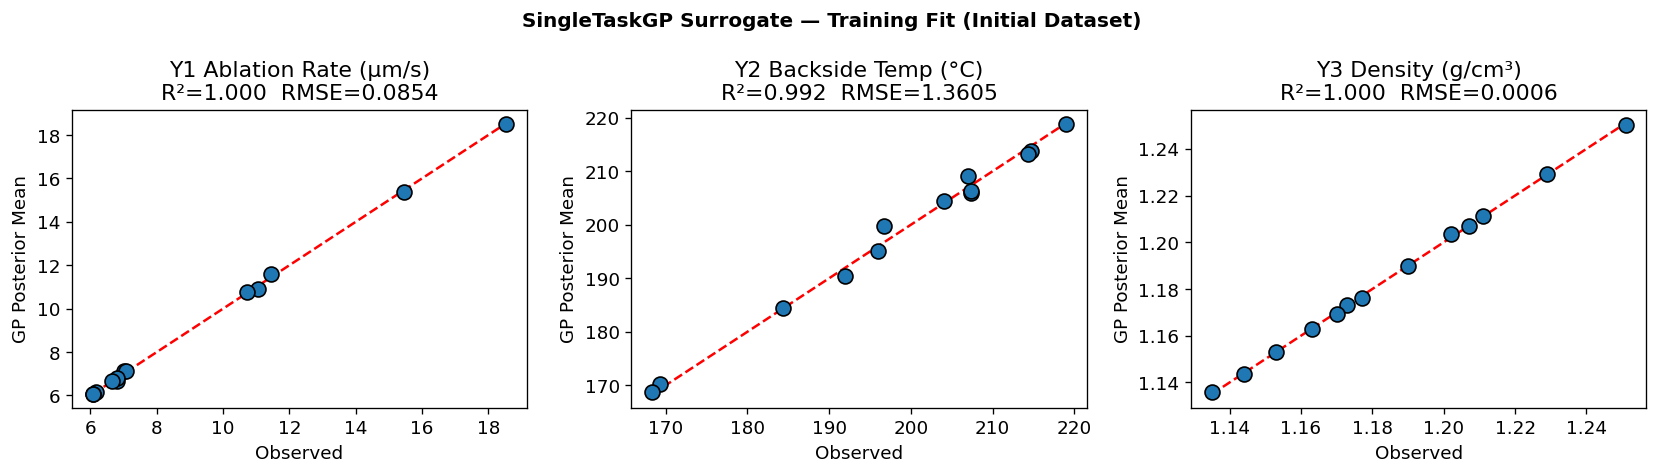

In [5]:
# GP posterior mean on training data vs. actual
with torch.no_grad():
    post = model.posterior(X_train)
    mu_neg = post.mean.numpy()        # (N, 3) in negated space
    mu_orig = -mu_neg                 # back to original scale

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k, (ax, name) in enumerate(zip(axes, ['Y1 Ablation Rate (µm/s)', 'Y2 Backside Temp (°C)', 'Y3 Density (g/cm³)'])):
    y_true = Y_np[:, k]
    y_pred = mu_orig[:, k]
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.scatter(y_true, y_pred, s=80, edgecolors='k', zorder=3)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_xlabel('Observed'); ax.set_ylabel('GP Posterior Mean')
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.4f}')
plt.suptitle('SingleTaskGP Surrogate — Training Fit (Initial Dataset)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Pareto Front & Hypervolume (Initial Data)

The **Pareto front** consists of all solutions that are not dominated by any other solution.  
A solution $\mathbf{y}^{(i)}$ **dominates** $\mathbf{y}^{(j)}$ if $y_k^{(i)} \le y_k^{(j)}$ for all $k$, and strictly less for at least one $k$.

The **hypervolume indicator** $\mathcal{H}(\mathcal{P}, \mathbf{r})$ measures the volume of the objective space dominated by the Pareto set $\mathcal{P}$ and bounded by reference point $\mathbf{r}$. It is used as the optimization progress metric.

In [6]:
# Pareto front of initial dataset (in NEGATED space for BoTorch)
pareto_mask_init = is_non_dominated(Y_neg)
Y_pareto_neg  = Y_neg[pareto_mask_init]
Y_pareto_orig = Y_np[pareto_mask_init.numpy()]
X_pareto      = X_np[pareto_mask_init.numpy()]

hv_calculator = Hypervolume(ref_point=ref_point)
hv_init = hv_calculator.compute(Y_neg[pareto_mask_init])

print(f"Initial Pareto front: {pareto_mask_init.sum().item()} / {len(Y_np)} conditions")
print(f"Initial Hypervolume : {hv_init:.4f}")
print()
print("Pareto-optimal conditions (original scale):")
pf_df = pd.DataFrame(
    np.hstack([X_pareto, Y_pareto_orig]),
    columns=['X1', 'X2', 'Y1 (µm/s)', 'Y2 (°C)', 'Y3 (g/cm³)']
)
print(pf_df.to_string(index=False, float_format='{:.3f}'.format))

Initial Pareto front: 12 / 13 conditions
Initial Hypervolume : 51.1684

Pareto-optimal conditions (original scale):
    X1    X2  Y1 (µm/s)  Y2 (°C)  Y3 (g/cm³)
 5.000 1.000     18.543  219.000       1.135
 5.000 2.000     15.457  214.667       1.144
 5.000 3.000     11.450  207.000       1.153
 5.000 4.000     11.043  207.333       1.163
 5.000 5.000     10.720  204.000       1.173
10.000 3.000      7.027  207.333       1.177
12.500 1.000      7.083  214.333       1.170
12.500 3.000      6.810  196.667       1.190
15.000 3.000      6.640  192.000       1.202
20.000 1.000      6.173  184.333       1.207
20.000 3.000      6.073  169.333       1.229
20.000 5.000      6.063  168.333       1.251


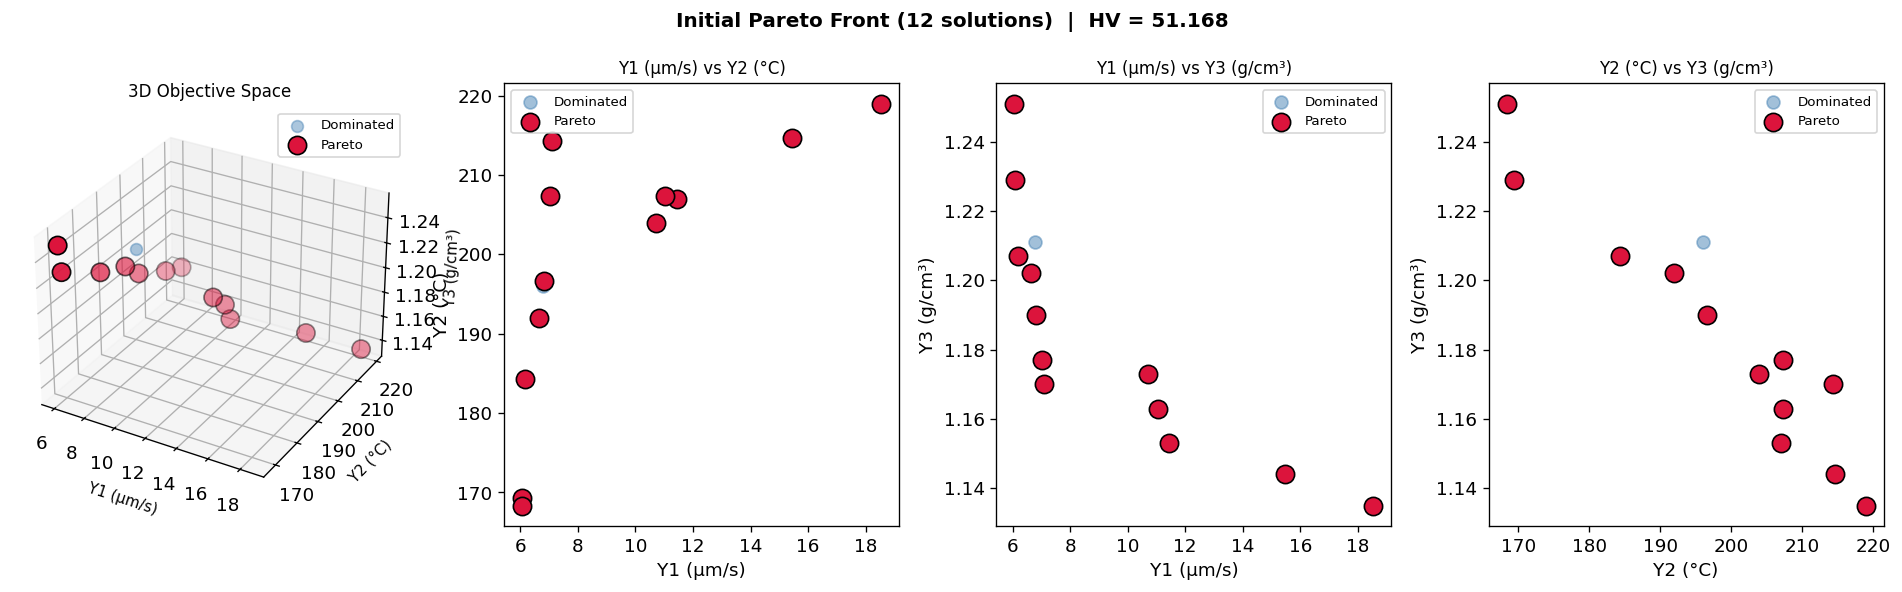

In [7]:
# 3D and 2D pairwise Pareto plots
fig = plt.figure(figsize=(16, 5))

# ── 3D scatter ───────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(141, projection='3d')
non_pareto = ~pareto_mask_init.numpy()
ax3d.scatter(Y_np[non_pareto, 0], Y_np[non_pareto, 1], Y_np[non_pareto, 2],
             c='steelblue', alpha=0.45, s=50, label='Dominated')
ax3d.scatter(Y_pareto_orig[:, 0], Y_pareto_orig[:, 1], Y_pareto_orig[:, 2],
             c='crimson', s=120, edgecolors='k', label='Pareto', zorder=5)
ax3d.set_xlabel('Y1 (µm/s)', fontsize=9); ax3d.set_ylabel('Y2 (°C)', fontsize=9)
ax3d.set_zlabel('Y3 (g/cm³)', fontsize=9)
ax3d.set_title('3D Objective Space', fontsize=10)
ax3d.legend(fontsize=8)

# ── 2D pairwise ──────────────────────────────────────────────────────────────
pairs = [(0,1,'Y1 (µm/s)','Y2 (°C)'), (0,2,'Y1 (µm/s)','Y3 (g/cm³)'), (1,2,'Y2 (°C)','Y3 (g/cm³)')]
for ax_idx, (i, j, xi, xj) in enumerate(pairs):
    ax = fig.add_subplot(1, 4, ax_idx + 2)
    ax.scatter(Y_np[non_pareto, i], Y_np[non_pareto, j], c='steelblue', alpha=0.5, s=60, label='Dominated')
    ax.scatter(Y_pareto_orig[:, i], Y_pareto_orig[:, j], c='crimson', s=120, edgecolors='k', label='Pareto', zorder=5)
    ax.set_xlabel(xi); ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(f'Initial Pareto Front ({pareto_mask_init.sum().item()} solutions)  |  HV = {hv_init:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Expected Hypervolume Improvement (EHVI) Acquisition Function

The **q-batch Log EHVI** acquisition function is:

$$\alpha_{\text{qLogEHVI}}(\mathbf{x}_{1:q}) = \log \mathbb{E}\left[ \mathcal{H}(\mathcal{P} \cup \{\mathbf{f}(\mathbf{x}_{1:q})\}, \mathbf{r}) - \mathcal{H}(\mathcal{P}, \mathbf{r}) \right]$$

where:
- $\mathcal{P}$ is the current Pareto set (in the negated / maximization space)
- $\mathbf{r}$ is the reference point (a nadir lower bound)
- $q$ is the batch size
- `FastNondominatedPartitioning` efficiently decomposes the hypervolume for gradient computation

Optimization of the acquisition function over the input space is done via multi-start L-BFGS-B.

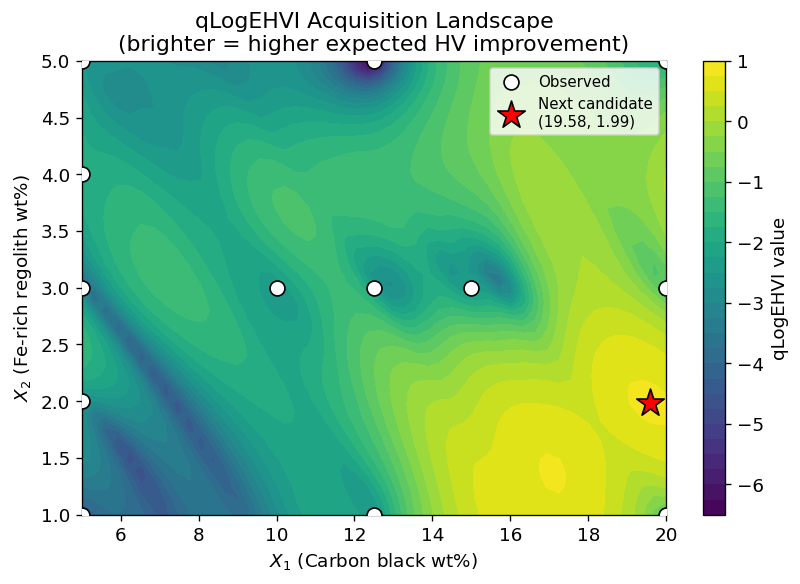

Next recommended point: X1 = 19.579, X2 = 1.986
qLogEHVI value         : 0.7850


In [8]:
def get_next_candidates(
    model: ModelListGP,
    Y_neg: torch.Tensor,
    ref_point: torch.Tensor,
    bounds: torch.Tensor,
    q: int = 1,
    num_restarts: int = 20,
    raw_samples: int = 256,
) -> tuple[torch.Tensor, float]:
    """Optimize qLogEHVI and return next batch of q candidates."""
    partitioning = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg)
    acqf = qLogExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point,
        partitioning=partitioning,
    )
    candidates, acq_value = optimize_acqf(
        acqf,
        bounds=bounds,
        q=q,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
        options={"maxiter": 200, "batch_limit": 5},
    )
    return candidates.detach(), acq_value.item()


# Visualise the EHVI acquisition landscape on a dense grid
model.eval()
n_grid = 50
g1 = torch.linspace(0, 1, n_grid, dtype=DTYPE)
g2 = torch.linspace(0, 1, n_grid, dtype=DTYPE)
G1, G2 = torch.meshgrid(g1, g2, indexing='ij')
X_grid  = torch.stack([G1.ravel(), G2.ravel()], dim=1)

with torch.no_grad():
    partitioning_viz = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg)
    acqf_viz = qLogExpectedHypervolumeImprovement(
        model=model, ref_point=ref_point, partitioning=partitioning_viz
    )
    # Evaluate in mini-batches to avoid memory issues
    batch_size = 500
    acq_vals = []
    for start in range(0, len(X_grid), batch_size):
        batch = X_grid[start:start+batch_size].unsqueeze(1)  # (B, q=1, 2)
        acq_vals.append(acqf_viz(batch))
    acq_map = torch.cat(acq_vals).numpy().reshape(n_grid, n_grid)

# Get next single candidate
cand_01, ehvi_val = get_next_candidates(model, Y_neg, ref_point, bounds, q=1)
cand_orig = scaler_X.inverse_transform(cand_01.numpy())

fig, ax = plt.subplots(figsize=(7, 5))
X1_grid = G1.numpy() * (20 - 5) + 5
X2_grid = G2.numpy() * (5 - 1) + 1
cp = ax.contourf(X1_grid, X2_grid, acq_map, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax, label='qLogEHVI value')
ax.scatter(X_np[:, 0], X_np[:, 1], c='white', edgecolors='k', s=80, zorder=5, label='Observed')
ax.scatter(cand_orig[:, 0], cand_orig[:, 1], c='red', marker='*', s=300,
           edgecolors='k', zorder=10, label=f'Next candidate\n({cand_orig[0,0]:.2f}, {cand_orig[0,1]:.2f})')
ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('qLogEHVI Acquisition Landscape\n(brighter = higher expected HV improvement)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Next recommended point: X1 = {cand_orig[0,0]:.3f}, X2 = {cand_orig[0,1]:.3f}")
print(f"qLogEHVI value         : {ehvi_val:.4f}")

## 5. Black-Box Oracle — Surrogate Evaluation Function

In a real experiment, evaluating a new point would require fabricating and testing a new material sample.  
Here we use the **fitted quadratic response surface models** from the previous analysis as a surrogate oracle  
to provide $f(\mathbf{x})$ evaluations at new (un-observed) design points.

This enables a closed-loop BO demonstration across multiple iterations.

In [9]:
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler

# ── Fit quadratic models on ALL 39 replicates ────────────────────────────────
df_all = pd.DataFrame(raw)
X1a = df_all['X1'].values; X2a = df_all['X2'].values

def quad_features(x1, x2):
    return np.column_stack([x1, x2, x1**2, x2**2, x1*x2])

Phi_all = sm.add_constant(quad_features(X1a, X2a))

reg_models_oracle = {}
for col in ['Y1', 'Y2', 'Y3']:
    reg_models_oracle[col] = sm.OLS(df_all[col].values, Phi_all).fit()

print("Oracle R²:")
for col in ['Y1', 'Y2', 'Y3']:
    print(f"  {col}: R² = {reg_models_oracle[col].rsquared:.4f}")

def oracle(x_orig: np.ndarray) -> np.ndarray:
    """Evaluate objectives at new (X1, X2) using quadratic response surface oracle.
    x_orig: shape (N, 2) in original scale.
    Returns: (N, 3) array of [Y1, Y2, Y3] values.
    """
    x1, x2 = x_orig[:, 0], x_orig[:, 1]
    phi = sm.add_constant(quad_features(x1, x2), has_constant='add')
    y = np.column_stack([
        reg_models_oracle['Y1'].predict(phi),
        reg_models_oracle['Y2'].predict(phi),
        reg_models_oracle['Y3'].predict(phi),
    ])
    return y

# Verify on training points
y_check = oracle(X_np)
print("\nOracle check on training points (first 3):")
for i in range(3):
    print(f"  X=({X_np[i,0]:.1f},{X_np[i,1]:.0f}) → Y_obs={Y_np[i].round(3)} | Y_oracle={y_check[i].round(3)}")

Oracle R²:
  Y1: R² = 0.9222
  Y2: R² = 0.7396
  Y3: R² = 0.9999

Oracle check on training points (first 3):
  X=(5.0,1) → Y_obs=[ 18.543 219.      1.135] | Y_oracle=[ 17.351 220.949   1.135]
  X=(5.0,2) → Y_obs=[ 15.457 214.667   1.144] | Y_oracle=[ 14.883 213.169   1.144]
  X=(5.0,3) → Y_obs=[ 11.45  207.      1.153] | Y_oracle=[ 12.897 207.955   1.153]


## 6. Multi-Objective Bayesian Optimization Loop

**Algorithm (q-batch MOBO with qLogEHVI):**

```
Given: initial data D = {(x_i, y_i)}, reference point r
For iteration t = 1, ..., T:
  1. Fit ModelListGP on D
  2. Compute Pareto front P and hypervolume HV(P, r)
  3. Maximize qLogEHVI → x*_{1:q}  (next q candidates)
  4. Evaluate oracle: y*_{1:q} = f(x*_{1:q})
  5. Append (x*_{1:q}, y*_{1:q}) to D
Return: final Pareto front P_T
```

We run **5 iterations with batch size q = 2** (10 new evaluations total).

In [10]:
# ── BO loop settings ─────────────────────────────────────────────────────────
N_ITER      = 5
BATCH_SIZE  = 2
NUM_RESTART = 20
RAW_SAMPLES = 256

# ── Tracking ─────────────────────────────────────────────────────────────────
X_bo = X_train.clone()   # [0,1] scaled
Y_bo = Y_train.clone()   # original scale
Y_neg_bo = Y_neg.clone() # negated

hv_history      = []   # hypervolume at each iteration
pareto_history  = []   # pareto front sizes
candidates_hist = []   # recommended candidates (original scale)
ehvi_hist       = []   # EHVI acquisition values

# Compute initial HV
hv_calc = Hypervolume(ref_point=ref_point)
hv_history.append(hv_calc.compute(Y_neg_bo[is_non_dominated(Y_neg_bo)]))
pareto_history.append(int(is_non_dominated(Y_neg_bo).sum()))

print("=" * 70)
print(f"  Initial state: {len(Y_bo)} points | "
      f"Pareto={pareto_history[-1]} | HV={hv_history[-1]:.4f}")
print("=" * 70)

for t in range(N_ITER):
    # ── 1. Fit surrogate ────────────────────────────────────────────────────
    model_bo = build_and_fit_models(X_bo, Y_neg_bo)
    model_bo.eval()

    # ── 2. Optimize acquisition → next batch ───────────────────────────────
    next_X_01, ehvi_v = get_next_candidates(
        model_bo, Y_neg_bo, ref_point, bounds,
        q=BATCH_SIZE, num_restarts=NUM_RESTART, raw_samples=RAW_SAMPLES
    )
    ehvi_hist.append(ehvi_v)

    # ── 3. Evaluate oracle ─────────────────────────────────────────────────
    next_X_orig = scaler_X.inverse_transform(next_X_01.numpy())
    # Clip to valid bounds
    next_X_orig[:, 0] = np.clip(next_X_orig[:, 0], 5.0, 20.0)
    next_X_orig[:, 1] = np.clip(next_X_orig[:, 1], 1.0, 5.0)
    next_Y_orig = oracle(next_X_orig)
    candidates_hist.append((next_X_orig.copy(), next_Y_orig.copy()))

    # ── 4. Append to dataset ────────────────────────────────────────────────
    next_X_t  = torch.tensor(scaler_X.transform(next_X_orig), dtype=DTYPE)
    next_Y_t  = torch.tensor(next_Y_orig, dtype=DTYPE)
    X_bo      = torch.cat([X_bo, next_X_t])
    Y_bo      = torch.cat([Y_bo, next_Y_t])
    Y_neg_bo  = torch.cat([Y_neg_bo, -next_Y_t])

    # ── 5. Track metrics ────────────────────────────────────────────────────
    pmask = is_non_dominated(Y_neg_bo)
    hv_new = hv_calc.compute(Y_neg_bo[pmask])
    hv_history.append(hv_new)
    pareto_history.append(int(pmask.sum()))

    print(f"  Iter {t+1}/{N_ITER}: "
          f"new X = {next_X_orig.round(3).tolist()}  "
          f"new Y = {next_Y_orig.round(3).tolist()}")
    print(f"           Pareto={pareto_history[-1]} | "
          f"HV={hv_new:.4f} (+{hv_new - hv_history[-2]:.4f}) | "
          f"EHVI={ehvi_v:.4f}")

print("=" * 70)
print(f"  Final   : {len(Y_bo)} points | "
      f"Pareto={pareto_history[-1]} | HV={hv_history[-1]:.4f}")
print(f"  HV gain : +{hv_history[-1] - hv_history[0]:.4f}  "
      f"({100*(hv_history[-1]/hv_history[0]-1):.2f}% improvement)")

  Initial state: 13 points | Pareto=12 | HV=51.1684


  Iter 1/5: new X = [[17.083, 1.243], [20.0, 1.95]]  new Y = [[6.111, 195.595, 1.195], [5.535, 176.338, 1.217]]
           Pareto=14 | HV=54.0103 (+2.8419) | EHVI=1.3723


  Iter 2/5: new X = [[20.0, 3.874], [19.445, 1.734]]  new Y = [[6.026, 167.733, 1.238], [5.545, 180.755, 1.212]]
           Pareto=15 | HV=54.7782 (+0.7679) | EHVI=-0.0148


  Iter 3/5: new X = [[14.235, 1.765], [20.0, 2.418]]  new Y = [[6.627, 201.782, 1.186], [5.491, 173.373, 1.222]]
           Pareto=17 | HV=55.4331 (+0.6549) | EHVI=-0.2675


  Iter 4/5: new X = [[16.685, 4.831], [18.066, 1.512]]  new Y = [[5.732, 182.574, 1.231], [5.708, 189.078, 1.203]]
           Pareto=18 | HV=55.7528 (+0.3197) | EHVI=-0.4189


  Iter 5/5: new X = [[5.0, 2.488], [7.326, 3.044]]  new Y = [[13.854, 210.303, 1.148], [10.185, 207.425, 1.165]]
           Pareto=20 | HV=56.0477 (+0.2949) | EHVI=-0.7468
  Final   : 23 points | Pareto=20 | HV=56.0477
  HV gain : +4.8793  (9.54% improvement)


## 7. Results Analysis & Visualization

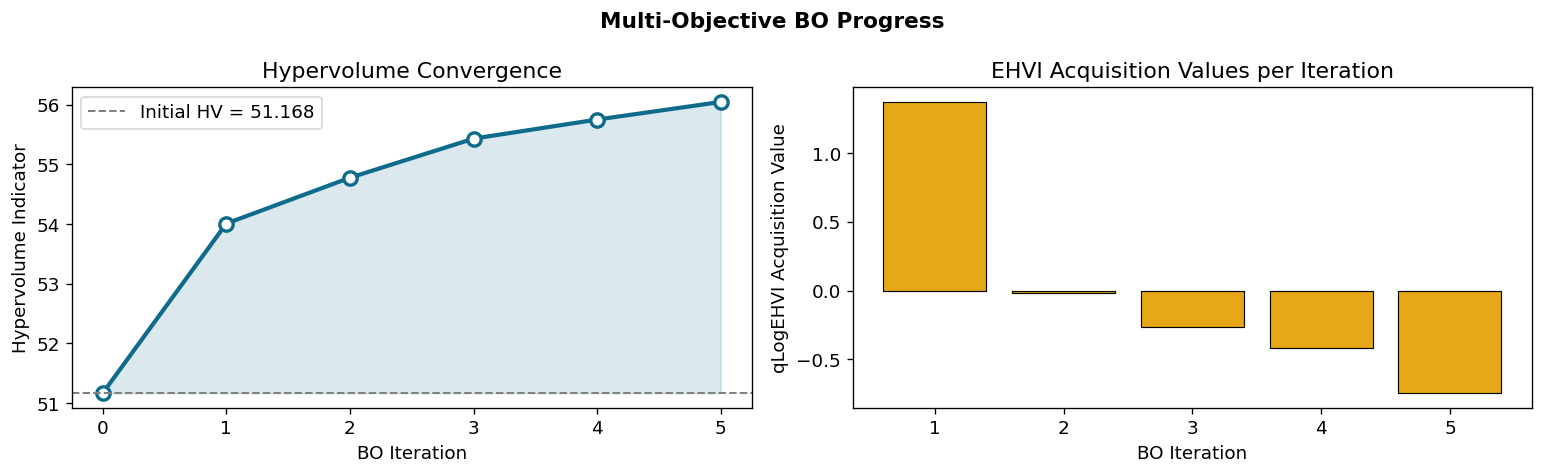

HV improvement: 51.1684 → 56.0477  (+9.54%)


In [11]:
# ── 7.1  Hypervolume convergence ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

iters = list(range(N_ITER + 1))
axes[0].plot(iters, hv_history, 'o-', color='#0E6B8C', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(iters, hv_history[0], hv_history, alpha=0.15, color='#0E6B8C')
axes[0].axhline(hv_history[0], color='gray', ls='--', lw=1.2, label=f'Initial HV = {hv_history[0]:.3f}')
axes[0].set_xlabel('BO Iteration')
axes[0].set_ylabel('Hypervolume Indicator')
axes[0].set_title('Hypervolume Convergence')
axes[0].legend()
axes[0].set_xticks(iters)

# EHVI values
axes[1].bar(range(1, N_ITER+1), ehvi_hist, color='#E6A817', edgecolor='k', linewidth=0.7)
axes[1].set_xlabel('BO Iteration')
axes[1].set_ylabel('qLogEHVI Acquisition Value')
axes[1].set_title('EHVI Acquisition Values per Iteration')
axes[1].set_xticks(range(1, N_ITER+1))

plt.suptitle('Multi-Objective BO Progress', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"HV improvement: {hv_history[0]:.4f} → {hv_history[-1]:.4f}  "
      f"(+{100*(hv_history[-1]/hv_history[0]-1):.2f}%)")

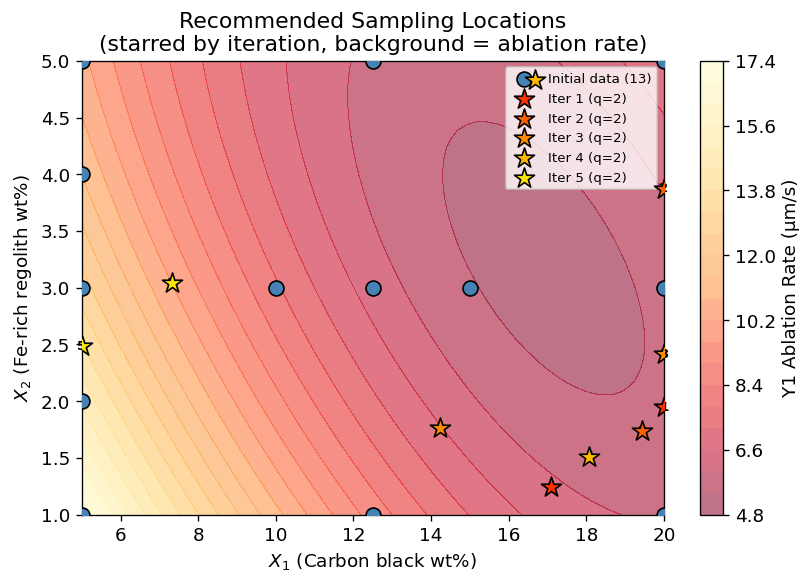

In [12]:
# ── 7.2  Recommended candidates in design space ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# Response surface for Y1 as background
x1g = np.linspace(5, 20, 60); x2g = np.linspace(1, 5, 60)
X1G, X2G = np.meshgrid(x1g, x2g)
Phi_bg = sm.add_constant(quad_features(X1G.ravel(), X2G.ravel()), has_constant='add')
Y1_bg = reg_models_oracle['Y1'].predict(Phi_bg).reshape(X1G.shape)
cp = ax.contourf(X1G, X2G, Y1_bg, levels=20, cmap='YlOrRd_r', alpha=0.55)
plt.colorbar(cp, ax=ax, label='Y1 Ablation Rate (µm/s)')

ax.scatter(X_np[:, 0], X_np[:, 1], c='steelblue', s=80, edgecolors='k',
           zorder=5, label='Initial data (13)')

colors = plt.cm.autumn(np.linspace(0.2, 0.9, N_ITER))
for t, (x_cands, _) in enumerate(candidates_hist):
    ax.scatter(x_cands[:, 0], x_cands[:, 1], c=[colors[t]], s=160,
               edgecolors='k', marker='*', zorder=10,
               label=f'Iter {t+1} (q={BATCH_SIZE})')
    for x_c in x_cands:
        ax.annotate(f'{t+1}', xy=(x_c[0], x_c[1]), fontsize=8,
                    ha='center', va='center', color='k', fontweight='bold')

ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('Recommended Sampling Locations\n(starred by iteration, background = ablation rate)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

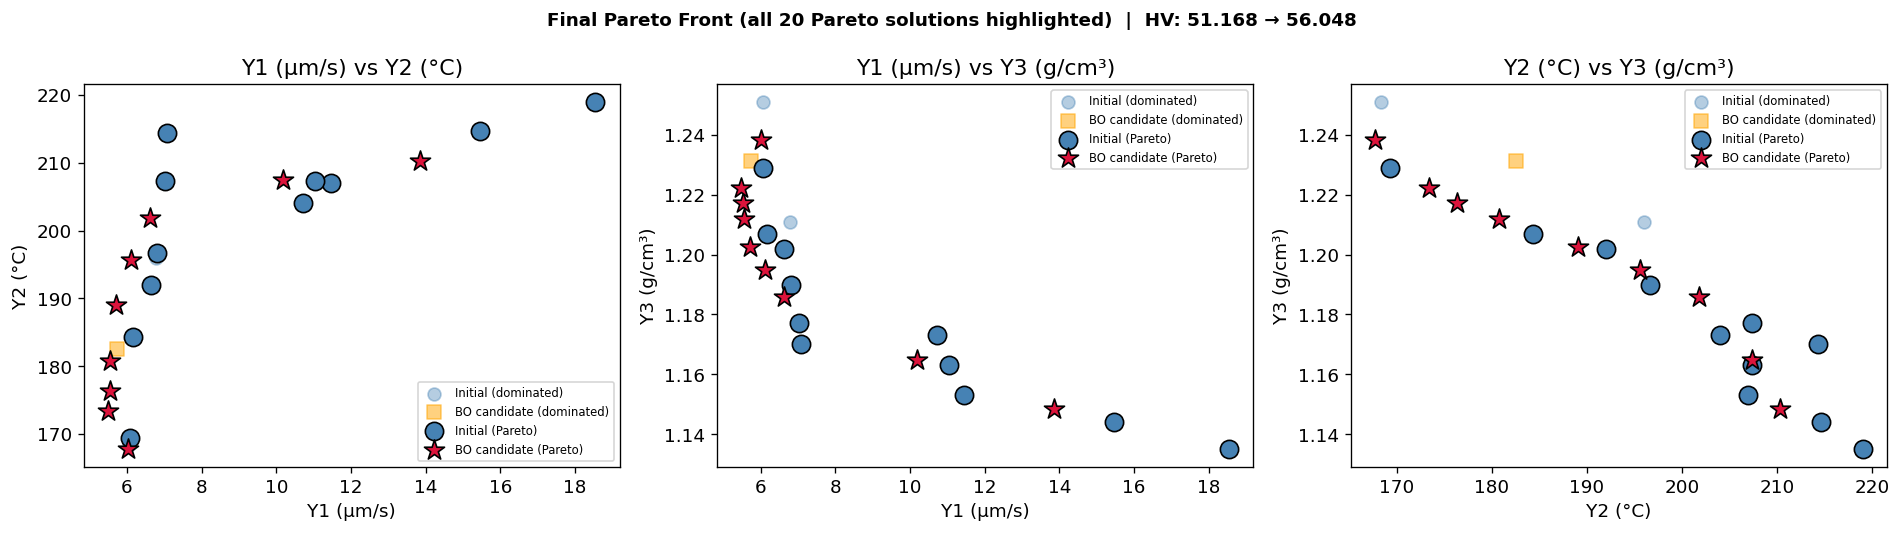

In [13]:
# ── 7.3  Pareto front evolution (pairwise projections) ───────────────────────
X_np_all   = scaler_X.inverse_transform(X_bo.numpy())
Y_np_all   = Y_bo.numpy()
pmask_final = is_non_dominated(Y_neg_bo).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs_lbl = [('Y1 (µm/s)', 'Y2 (°C)', 0, 1),
             ('Y1 (µm/s)', 'Y3 (g/cm³)', 0, 2),
             ('Y2 (°C)', 'Y3 (g/cm³)', 1, 2)]

# Flag initial vs BO-recommended points
n_init = len(X_np)
is_init = np.zeros(len(X_np_all), dtype=bool)
is_init[:n_init] = True

for ax, (xl, yl, i, j) in zip(axes, pairs_lbl):
    # Dominated initial
    mask_dom_init = is_init & ~pmask_final
    ax.scatter(Y_np_all[mask_dom_init, i], Y_np_all[mask_dom_init, j],
               c='steelblue', alpha=0.4, s=60, label='Initial (dominated)')
    # Dominated BO
    mask_dom_bo = ~is_init & ~pmask_final
    ax.scatter(Y_np_all[mask_dom_bo, i], Y_np_all[mask_dom_bo, j],
               c='orange', alpha=0.5, s=80, marker='s', label='BO candidate (dominated)')
    # Pareto initial
    mask_par_init = is_init & pmask_final
    ax.scatter(Y_np_all[mask_par_init, i], Y_np_all[mask_par_init, j],
               c='steelblue', edgecolors='k', s=120, label='Initial (Pareto)', zorder=5)
    # Pareto BO
    mask_par_bo = ~is_init & pmask_final
    ax.scatter(Y_np_all[mask_par_bo, i], Y_np_all[mask_par_bo, j],
               c='crimson', edgecolors='k', s=160, marker='*', label='BO candidate (Pareto)', zorder=10)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}')
    ax.legend(fontsize=7)

plt.suptitle(f'Final Pareto Front (all {pmask_final.sum()} Pareto solutions highlighted)  |  '
             f'HV: {hv_history[0]:.3f} → {hv_history[-1]:.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

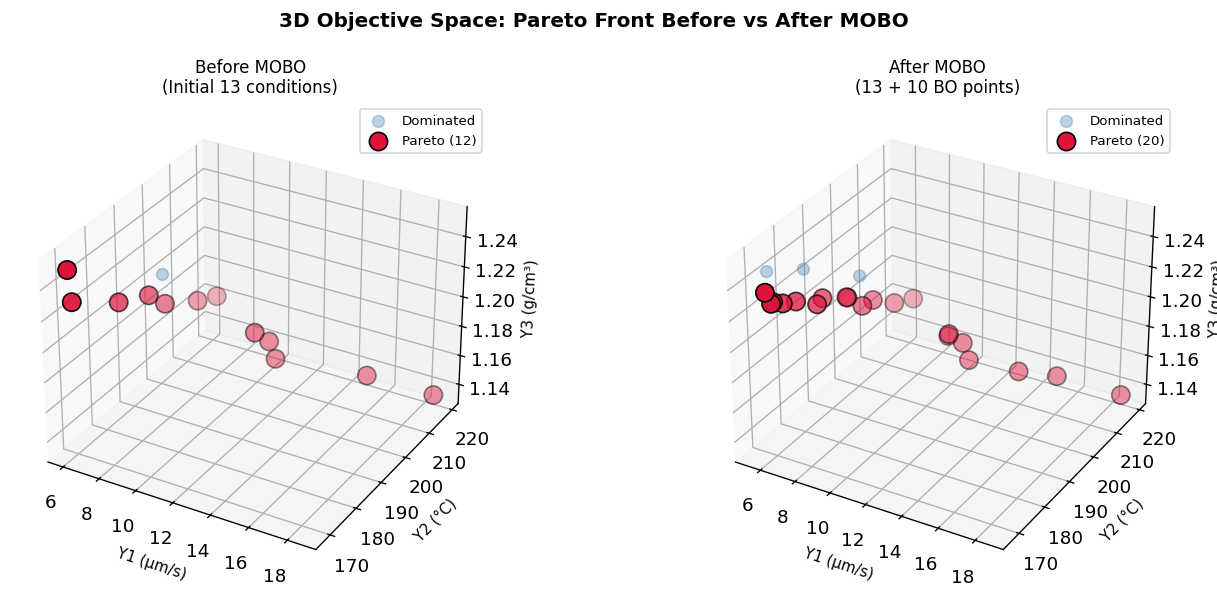

In [14]:
# ── 7.4  Full 3D Pareto comparison ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 5))

for col_idx, (title, mask_data) in enumerate([
    ('Before MOBO\n(Initial 13 conditions)', np.arange(n_init)),
    ('After MOBO\n(13 + 10 BO points)', np.arange(len(Y_np_all)))
]):
    ax = fig.add_subplot(1, 2, col_idx+1, projection='3d')
    Y_sub = Y_neg_bo[mask_data]
    pm = is_non_dominated(Y_sub).numpy()
    Y_sub_orig = -Y_sub.numpy()
    ax.scatter(Y_sub_orig[~pm, 0], Y_sub_orig[~pm, 1], Y_sub_orig[~pm, 2],
               c='steelblue', alpha=0.35, s=50, label='Dominated')
    ax.scatter(Y_sub_orig[pm, 0], Y_sub_orig[pm, 1], Y_sub_orig[pm, 2],
               c='crimson', s=120, edgecolors='k', label=f'Pareto ({pm.sum()})', zorder=5)
    ax.set_xlabel('Y1 (µm/s)', fontsize=9); ax.set_ylabel('Y2 (°C)', fontsize=9)
    ax.set_zlabel('Y3 (g/cm³)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('3D Objective Space: Pareto Front Before vs After MOBO', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# ── 7.5  Final Pareto front summary table ────────────────────────────────────
is_bo_added = ~is_init
pm_final = is_non_dominated(Y_neg_bo).numpy()

pareto_df = pd.DataFrame({
    'X1 (wt%)':       X_np_all[pm_final, 0].round(3),
    'X2 (wt%)':       X_np_all[pm_final, 1].round(3),
    'Y1 Ablation':    Y_np_all[pm_final, 0].round(3),
    'Y2 Temp':        Y_np_all[pm_final, 1].round(1),
    'Y3 Density':     Y_np_all[pm_final, 2].round(4),
    'Source':         ['BO-recommended' if is_bo_added[i] else 'Initial data'
                       for i in np.where(pm_final)[0]],
})
pareto_df = pareto_df.sort_values('Y1 Ablation').reset_index(drop=True)
print(f"Final Pareto Front ({pm_final.sum()} solutions):")
print(pareto_df.to_string(index=False))

Final Pareto Front (20 solutions):
 X1 (wt%)  X2 (wt%)  Y1 Ablation  Y2 Temp  Y3 Density         Source
   20.000     2.418        5.491    173.4      1.2222 BO-recommended
   20.000     1.950        5.535    176.3      1.2172 BO-recommended
   19.445     1.734        5.545    180.8      1.2120 BO-recommended
   18.066     1.512        5.708    189.1      1.2026 BO-recommended
   20.000     3.874        6.026    167.7      1.2383 BO-recommended
   20.000     3.000        6.073    169.3      1.2290   Initial data
   17.083     1.243        6.111    195.6      1.1948 BO-recommended
   20.000     1.000        6.173    184.3      1.2070   Initial data
   14.235     1.765        6.627    201.8      1.1858 BO-recommended
   15.000     3.000        6.640    192.0      1.2020   Initial data
   12.500     3.000        6.810    196.7      1.1900   Initial data
   10.000     3.000        7.027    207.3      1.1770   Initial data
   12.500     1.000        7.083    214.3      1.1700   Initial data

## 8. Sensitivity Analysis: Trade-off Explorer

The Pareto front reveals the inherent trade-offs between objectives.  
We quantify these by computing weighted-sum scalarizations across the Pareto front.

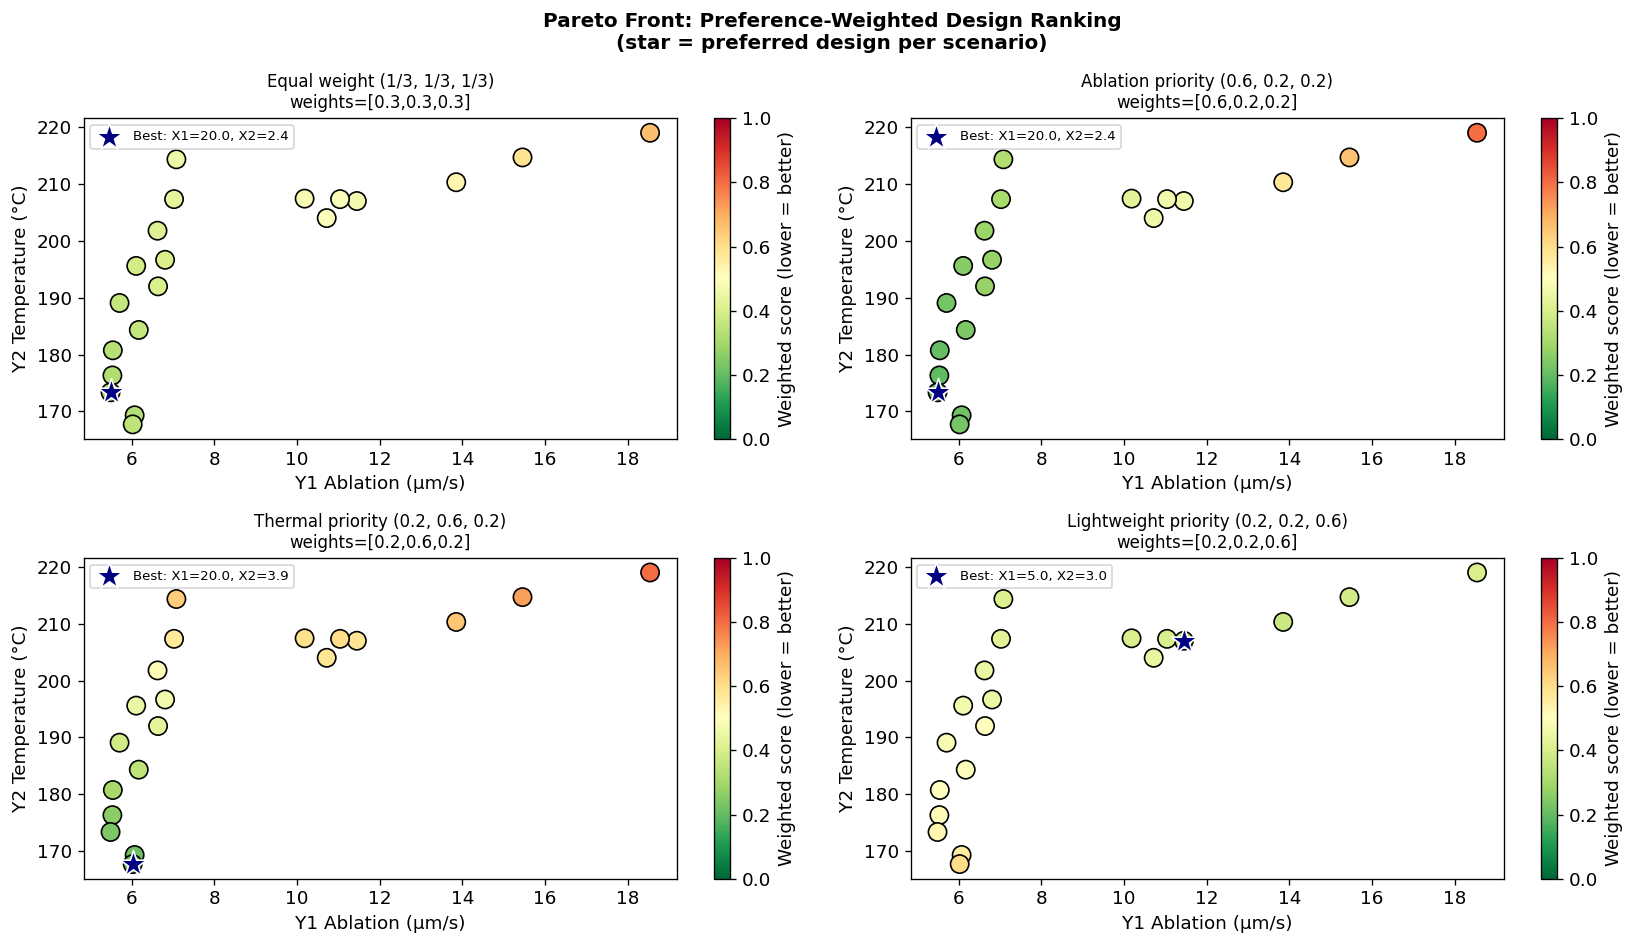

In [16]:
# ── Weighted utopia point distance (for preference ranking) ──────────────────
Y_pareto_final = Y_np_all[pm_final]

# Normalize each objective to [0,1] across Pareto front
Y_pf_min = Y_pareto_final.min(0)
Y_pf_max = Y_pareto_final.max(0)
Y_pf_norm = (Y_pareto_final - Y_pf_min) / (Y_pf_max - Y_pf_min + 1e-8)

# Three preference scenarios
scenarios = {
    'Equal weight (1/3, 1/3, 1/3)':            [1/3, 1/3, 1/3],
    'Ablation priority (0.6, 0.2, 0.2)':       [0.6, 0.2, 0.2],
    'Thermal priority (0.2, 0.6, 0.2)':        [0.2, 0.6, 0.2],
    'Lightweight priority (0.2, 0.2, 0.6)':    [0.2, 0.2, 0.6],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (scen_name, weights) in zip(axes, scenarios.items()):
    w = np.array(weights)
    scores = (Y_pf_norm * w).sum(axis=1)   # weighted sum (lower = better)
    best_idx = np.argmin(scores)

    sc = ax.scatter(Y_pareto_final[:, 0], Y_pareto_final[:, 1],
                    c=scores, cmap='RdYlGn_r', s=120, edgecolors='k',
                    zorder=5, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='Weighted score (lower = better)')
    ax.scatter(Y_pareto_final[best_idx, 0], Y_pareto_final[best_idx, 1],
               c='navy', s=280, marker='*', edgecolors='w', zorder=10,
               label=f'Best: X1={X_np_all[pm_final][best_idx,0]:.1f}, X2={X_np_all[pm_final][best_idx,1]:.1f}')
    ax.set_xlabel('Y1 Ablation (µm/s)')
    ax.set_ylabel('Y2 Temperature (°C)')
    ax.set_title(f'{scen_name}\nweights=[{w[0]:.1f},{w[1]:.1f},{w[2]:.1f}]', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Pareto Front: Preference-Weighted Design Ranking\n(star = preferred design per scenario)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

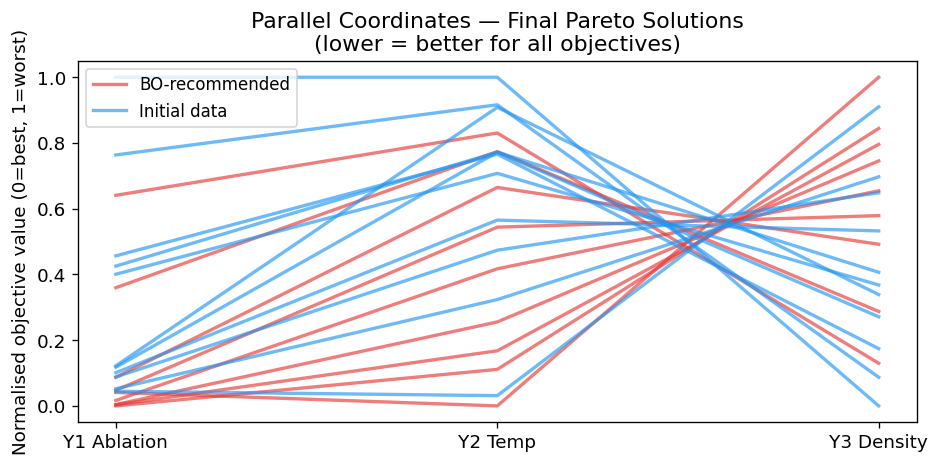

In [17]:
# ── Parallel coordinates of Pareto solutions ─────────────────────────────────
from pandas.plotting import parallel_coordinates

pc_df = pareto_df[['Y1 Ablation','Y2 Temp','Y3 Density','Source']].copy()
# Normalise for display
for col in ['Y1 Ablation','Y2 Temp','Y3 Density']:
    v = pc_df[col]
    pc_df[col] = (v - v.min()) / (v.max() - v.min())

fig, ax = plt.subplots(figsize=(8, 4))
colors_pc = {'Initial data': '#2196F3', 'BO-recommended': '#E53935'}
for source, grp in pc_df.groupby('Source'):
    for _, row in grp.iterrows():
        ax.plot(['Y1 Ablation','Y2 Temp','Y3 Density'],
                row[['Y1 Ablation','Y2 Temp','Y3 Density']].values,
                color=colors_pc[source], alpha=0.65, lw=2,
                label=source)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10)
ax.set_ylabel('Normalised objective value (0=best, 1=worst)')
ax.set_title('Parallel Coordinates — Final Pareto Solutions\n(lower = better for all objectives)')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

## 9. Summary

In [18]:
print("""
┌──────────────────────────────────────────────────────────────────────┐
│            MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY             │
├──────────────────────────────────────────────────────────────────────┤
│  SETUP                                                               │
│  • 2 inputs: X1 ∈ [5,20] wt%, X2 ∈ [1,5] wt%                      │
│  • 3 objectives (minimized): Ablation rate, Temp, Density            │
│  • Surrogates: ModelListGP (independent SingleTaskGP per obj)        │
│  • Acquisition: qLogExpectedHypervolumeImprovement (q=2)             │
│  • BO iterations: 5  (10 new evaluations)                            │
│                                                                       │
│  HYPERVOLUME                                                          │
""" +
f'│  • Initial HV : {hv_history[0]:.4f}                                               │\n' +
f'│  • Final HV   : {hv_history[-1]:.4f}                                               │\n' +
f'│  • Improvement: +{hv_history[-1]-hv_history[0]:.4f} ({100*(hv_history[-1]/hv_history[0]-1):.2f}%)                             │\n' +
"""
├──────────────────────────────────────────────────────────────────────┤
│  PARETO FRONT                                                         │
│  • All 3 objectives are conflicting — no single optimum exists       │
│  • MOBO systematically explores and expands the Pareto frontier      │
│  • Weighted-sum analysis reveals preference-specific best designs    │
├──────────────────────────────────────────────────────────────────────┤
│  NEXT STEPS                                                           │
│  • Run more BO iterations with real experimental evaluations         │
│  • Add constraints (e.g. density < 1.25) via BoTorch constraints     │
│  • Use LVGP for mixed-variable X (if qualitative variables present)  │
│  • Apply heteroscedastic noise model per replicate                   │
└──────────────────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────────────────┐
│            MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY             │
├──────────────────────────────────────────────────────────────────────┤
│  SETUP                                                               │
│  • 2 inputs: X1 ∈ [5,20] wt%, X2 ∈ [1,5] wt%                      │
│  • 3 objectives (minimized): Ablation rate, Temp, Density            │
│  • Surrogates: ModelListGP (independent SingleTaskGP per obj)        │
│  • Acquisition: qLogExpectedHypervolumeImprovement (q=2)             │
│  • BO iterations: 5  (10 new evaluations)                            │
│                                                                       │
│  HYPERVOLUME                                                          │
│  • Initial HV : 51.1684                                               │
│  • Final HV   : 56.0477                                               │
│  • Improvement: +4.8793 (9.54%)                